In [1]:
# import libraries 
import warnings
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import pandas as pd
from scipy import stats

warnings.filterwarnings('ignore') # Turns off warnings

### Read in and Prepare Data

In [2]:
ds = xr.open_dataset('storm_rainfall.nc')

lat_mask = (ds.lat >= 25) & (ds.lat <= 49)
lon_mask = (ds.lon >= -105) & (ds.lon <= -67)

rain = ds.sel(lat=lat_mask, lon=lon_mask)
rain = rain.where(rain != 0)

del ds

### Calculate rain rate

In [3]:
rain_rate = (rain.rain / rain.hits).where(rain.hits > 0)

del rain
rain_rate

<xarray.DataArray (storm: 53, lat: 576, lon: 912)> Size: 223MB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
...
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]], shape=(53, 576, 912))
Coordinates:
  * storm    (storm) <U9 2kB 'Milton' 'Helene' 'Francine' ... 'Fran' 'Bertha'
    year     (storm) int64 424B 2024 2024 2024 2024 2024 ... 1998 1997 1996 1996
    cat      (storm) float64 424B 3.0 4.0 2.0 1.0 1.0 ... 1.0 2.0 1.0 3.0 2.0
  * lat      (lat) float64 5kB 25.04 25.08 25.12 25.17 ... 48.92 48.96 49.0
  * lon      (lon) float64 7kB -105.0 -105.0 -104.9 ... -67.12 -67.08 -67.04

### Fit gamma distribution to full dataset

In [4]:
## flatten data into array for use on creating pdfs
rr= rain_rate.values.flatten()
rr = rr[~np.isnan(rr)]
rr = rr[~(rr==0)]

In [5]:
## fit gamma distribution to full dataset
sh_tot, loc_tot, sc_tot = stats.gamma.fit(rr, floc=0)
x = np.arange(loc_tot, np.max(rain_rate), 5)
pdf = stats.gamma.pdf(x, a=sh_tot, loc=loc_tot, scale=sc_tot)

### Subset data to first fifteen years

In [6]:
re = rain_rate.sel(storm=rain_rate.year <= 2010)
rl = rain_rate.sel(storm=rain_rate.year > 2010)

### Repeat distribution creation for each subset

In [7]:
## first for early period
rre = re.values.flatten()
rre = rre[~np.isnan(rre)]
rre = rre[~(rre==0)]

sh_e, loc_e, sc_e = stats.gamma.fit(rre, floc=0)
x_e = np.arange(loc_e, np.max(rre), 5)
pdf_e = stats.gamma.pdf(x_e, a=sh_e, loc=loc_e, scale=sc_e)

In [8]:
## now for later period
rrl = rl.values.flatten()
rrl = rrl[~np.isnan(rrl)]
rrl = rrl[~(rrl==0)]

sh_l, loc_l, sc_l = stats.gamma.fit(rrl, floc=0)
x_l = np.arange(loc_l, np.max(rrl), 5)
pdf_l = stats.gamma.pdf(x_l, a=sh_l, loc=loc_l, scale=sc_l)

In [ ]:
## test if distributions are statistically different
sig, pvalue = stats.ks_2samp(rrl, rre)
sig, pvalue

(np.float64(0.01996115094169104), np.float64(7.249605856269584e-181))

### Plot results

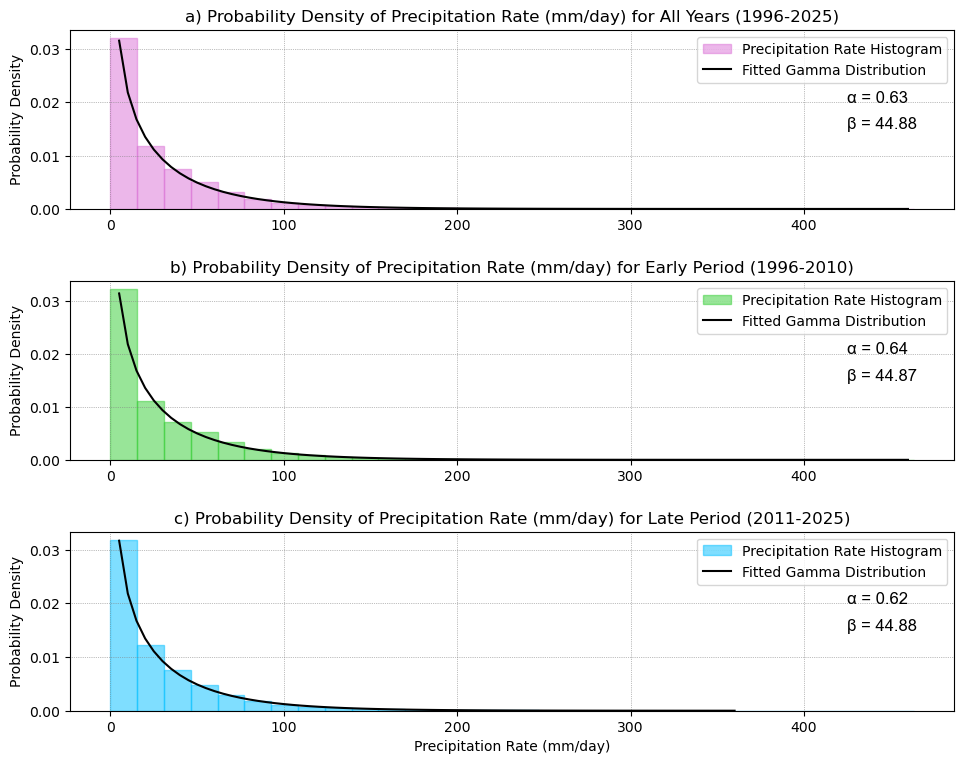

In [10]:
fig = plt.figure(figsize=(10,8))

all_data = np.hstack((rr, rre, rrl))
bins = np.histogram(all_data, bins=30)[1]

# add histogram of actual values (density=True allows for probability density)
ax = fig.add_subplot(311)
ax.hist(rr, bins=bins, alpha=0.5, density=True, color='orchid', edgecolor='orchid', label='Precipitation Rate Histogram')
ax.plot(x, pdf, color='black', label='Fitted Gamma Distribution')
ax.grid(color='gray', linestyle='dotted', linewidth=0.5)
ax.text(425, 0.02, f'α = {round(sh_tot,2)}', fontsize=12, color='black', name='Arial')
ax.text(425, 0.015, f'β = {round(sc_tot,2)}', fontsize=12, color='black', name='Arial')
ax.set_ylabel('Probability Density')
ax.set_title('a) Probability Density of Precipitation Rate (mm/day) for All Years (1996-2025)')
ax.legend()

ax1 = fig.add_subplot(312, sharex=ax)
ax1.hist(rre, bins=bins, alpha=0.5, density=True, color='limegreen', edgecolor='limegreen', label='Precipitation Rate Histogram')
ax1.plot(x_e, pdf_e, color='black', label='Fitted Gamma Distribution')
ax1.grid(color='gray', linestyle='dotted', linewidth=0.5)
ax1.text(425, 0.02, f'α = {round(sh_e,2)}', fontsize=12, color='black', name='Arial')
ax1.text(425, 0.015, f'β = {round(sc_e,2)}', fontsize=12, color='black', name='Arial')
ax1.set_ylabel('Probability Density')
ax1.set_title('b) Probability Density of Precipitation Rate (mm/day) for Early Period (1996-2010)')
ax1.legend()

ax2 = fig.add_subplot(313, sharex=ax)
ax2.hist(rrl, bins=bins, alpha=0.5, density=True, color='deepskyblue', edgecolor='deepskyblue', label='Precipitation Rate Histogram')
ax2.plot(x_l, pdf_l, color='black', label='Fitted Gamma Distribution')
ax2.grid(color='gray', linestyle='dotted', linewidth=0.5)
ax2.text(425, 0.02, f'α = {round(sh_l,2)}', fontsize=12, color='black', name='Arial')
ax2.text(425, 0.015, f'β = {round(sc_l,2)}', fontsize=12, color='black', name='Arial')
ax2.set_ylabel('Probability Density')
ax2.set_xlabel('Precipitation Rate (mm/day)')
ax2.set_title('c) Probability Density of Precipitation Rate (mm/day) for Late Period (2011-2025)')
ax2.legend()

plt.tight_layout(pad=2.0)
plt.savefig('PDFs_All.png',facecolor='w',dpi=400)

### Divide by storm category for late years and fit distributions

In [ ]:
r_lmn = rl.sel(storm=rl.cat <= 2)
r_lmj = rl.sel(storm=rl.cat > 2)

9

In [12]:
rr_lmj = r_lmj.values.flatten()
rr_lmj = rr_lmj[~np.isnan(rr_lmj)]
rr_lmj= rr_lmj[~(rr_lmj==0)]

sh_lmj, loc_lmj, sc_lmj = stats.gamma.fit(rr_lmj, floc=0)
x_lmj = np.arange(loc_lmj, np.max(rr_lmj), 5)
pdf_lmj= stats.gamma.pdf(x_lmj, a=sh_lmj, loc=loc_lmj, scale=sc_lmj)

In [13]:
rr_lmn = r_lmn.values.flatten()
rr_lmn = rr_lmn[~np.isnan(rr_lmn)]
rr_lmnn= rr_lmn[~(rr_lmn==0)]

sh_lmn, loc_lmn, sc_lmn = stats.gamma.fit(rr_lmn, floc=0)
x_lmn = np.arange(loc_lmn, np.max(rr_lmn), 5)
pdf_lmn = stats.gamma.pdf(x_lmn, a=sh_lmn, loc=loc_lmn, scale=sc_lmn)

### Divide by storm category for early years and fit distributions

In [14]:
r_emn = re.sel(storm=re.cat <= 2)
r_emj = re.sel(storm=re.cat > 2)

In [15]:
rr_emj = r_emj.values.flatten()
rr_emj = rr_emj[~np.isnan(rr_emj)]
rr_emj= rr_emj[~(rr_emj==0)]

sh_emj, loc_emj, sc_emj = stats.gamma.fit(rr_emj, floc=0)
x_emj = np.arange(loc_emj, np.max(rr_emj), 5)
pdf_emj= stats.gamma.pdf(x_emj, a=sh_emj, loc=loc_emj, scale=sc_emj)

In [16]:
rr_emn = r_emn.values.flatten()
rr_emn = rr_emn[~np.isnan(rr_emn)]
rr_emn= rr_emn[~(rr_emn==0)]

sh_emn, loc_emn, sc_emn = stats.gamma.fit(rr_emn, floc=0)
x_emn = np.arange(loc_emn, np.max(rr_emn), 5)
pdf_emn = stats.gamma.pdf(x_emn, a=sh_emn, loc=loc_emn, scale=sc_emn)

### Test if distributions for intensities are statistically different

In [17]:
## significance
sig, pvalue = stats.ks_2samp(rr_lmn, rr_emn)
sig, pvalue

(np.float64(0.026483756213400045), np.float64(8.641628463190434e-192))

In [21]:
## significance
sig, pvalue = stats.ks_2samp(rr_lmj, rr_emj)
sig, pvalue

(np.float64(0.02119991447316205), np.float64(6.530382123383422e-81))

### Plot results

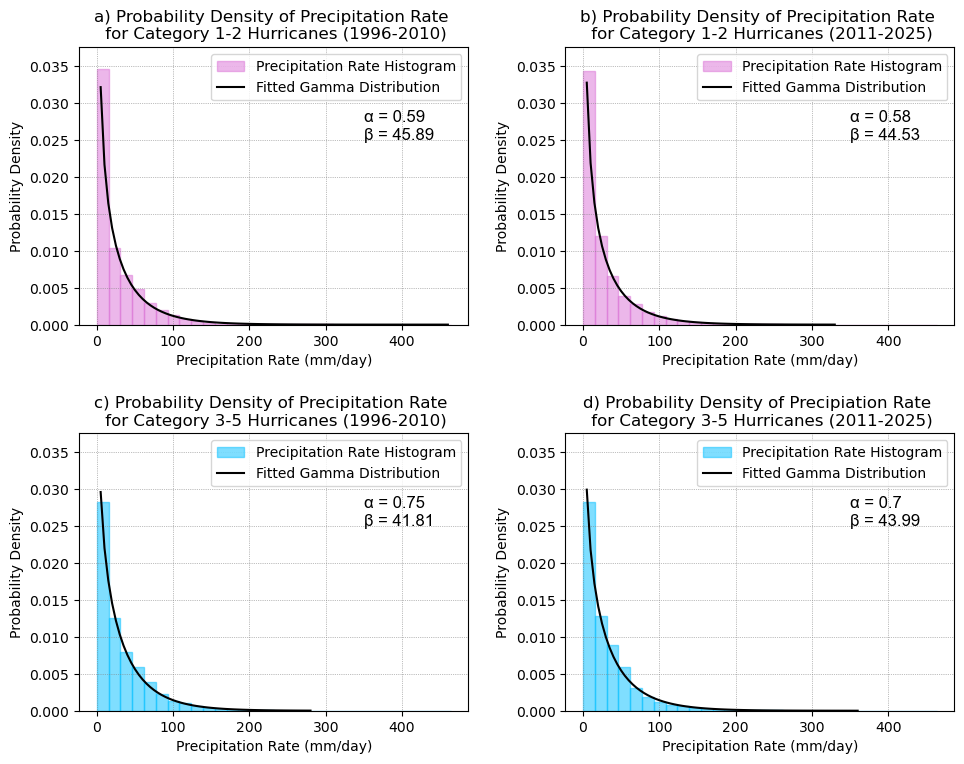

In [22]:
fig = plt.figure(figsize=(10,8))

all_data = np.hstack((rr_lmn, rr_lmj, rr_emn, rr_emj))
bins = np.histogram(all_data, bins=30)[1]

# add histogram of actual values (density=True allows for probability density)
ax = fig.add_subplot(222)
ax.hist(rr_lmn, bins=bins, alpha=0.5, density=True, color='orchid', edgecolor='orchid', label='Precipitation Rate Histogram')
ax.plot(x_lmn, pdf_lmn, color='black', label='Fitted Gamma Distribution')
ax.grid(color='gray', linestyle='dotted', linewidth=0.5)
ax.set_ylim(0,0.0375)
ax.text(350, 0.0275, f'α = {round(sh_lmn,2)}', fontsize=12, color='black', name='Arial')
ax.text(350, 0.025, f'β = {round(sc_lmn,2)}', fontsize=12, color='black', name='Arial')
ax.set_ylabel('Probability Density')
ax.set_xlabel('Precipitation Rate (mm/day)')
ax.set_title('b) Probability Density of Precipitation Rate \n for Category 1-2 Hurricanes (2011-2025)')
ax.legend()


ax1 = fig.add_subplot(221, sharex=ax)
ax1.hist(rr_emn, bins=bins, alpha=0.5, density=True, color='orchid', edgecolor='orchid', label='Precipitation Rate Histogram')
ax1.plot(x_emn, pdf_emn, color='black', label='Fitted Gamma Distribution')
ax1.grid(color='gray', linestyle='dotted', linewidth=0.5)
ax1.set_ylim(0,0.0375)
ax1.text(350, 0.0275, f'α = {round(sh_emn,2)}', fontsize=12, color='black', name='Arial')
ax1.text(350, 0.025, f'β = {round(sc_emn,2)}', fontsize=12, color='black', name='Arial')
ax1.set_ylabel('Probability Density')
ax1.set_xlabel('Precipitation Rate (mm/day)')
ax1.set_title('a) Probability Density of Precipitation Rate \n for Category 1-2 Hurricanes (1996-2010)')
ax1.legend()

ax2 = fig.add_subplot(224, sharex=ax)
ax2.hist(rr_lmj, bins=bins, alpha=0.5, density=True, color='deepskyblue', edgecolor='deepskyblue', label='Precipitation Rate Histogram')
ax2.plot(x_lmj, pdf_lmj, color='black', label='Fitted Gamma Distribution')
ax2.grid(color='gray', linestyle='dotted', linewidth=0.5)
ax2.set_ylim(0,0.0375)
ax2.text(350, 0.0275, f'α = {round(sh_lmj,2)}', fontsize=12, color='black', name='Arial')
ax2.text(350, 0.025, f'β = {round(sc_lmj,2)}', fontsize=12, color='black', name='Arial')
ax2.set_ylabel('Probability Density')
ax2.set_xlabel('Precipitation Rate (mm/day)')
ax2.set_title('d) Probability Density of Precipiation Rate \n for Category 3-5 Hurricanes (2011-2025)')
ax2.legend()

ax3 = fig.add_subplot(223, sharex=ax)
ax3.hist(rr_emj, bins=bins, alpha=0.5, density=True, color='deepskyblue', edgecolor='deepskyblue', label='Precipitation Rate Histogram')
ax3.plot(x_emj, pdf_emj, color='black', label='Fitted Gamma Distribution')
ax3.grid(color='gray', linestyle='dotted', linewidth=0.5)
ax3.set_ylim(0,0.0375)
ax3.text(350, 0.0275, f'α = {round(sh_emj,2)}', fontsize=12, color='black', name='Arial')
ax3.text(350, 0.025, f'β = {round(sc_emj,2)}', fontsize=12, color='black', name='Arial')
ax3.set_ylabel('Probability Density')
ax3.set_xlabel('Precipitation Rate (mm/day)')
ax3.set_title('c) Probability Density of Precipitation Rate \n for Category 3-5 Hurricanes (1996-2010)')
ax3.legend()

plt.tight_layout(pad=2.0)
plt.savefig('PDFs_Categories.png',facecolor='w',dpi=400)